In [38]:
from pathlib import Path
import math
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from itertools import islice
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

# Data Loader

In [2]:
def build_chart_manifest(audio_dir, token_dir):
    audio_dir = Path(audio_dir)
    token_dir = Path(token_dir)

    audio_files = {p.stem: p for p in audio_dir.glob("*.npz")}
    token_files = {p.stem: p for p in token_dir.glob("*.json")}

    common_ids = sorted(set(audio_files) & set(token_files))

    rows = []
    for chart_id in common_ids:
        npz_path = audio_files[chart_id]
        json_path = token_files[chart_id]

        audio_arr = np.load(npz_path)["audio_sequences"]
        with open(json_path, "r", encoding="utf-8") as f:
            token_data = json.load(f)

        rows.append({
            "chart_id": chart_id,
            "npz_path": str(npz_path),
            "json_path": str(json_path),
            "n_sequences_audio": int(audio_arr.shape[0]),
            "n_sequences_token": int(len(token_data)),
        })

    manifest_df = pd.DataFrame(rows)
    return manifest_df

def split_chart_manifest(manifest_df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8

    chart_ids = manifest_df["chart_id"].tolist()

    train_ids, temp_ids = train_test_split(
        chart_ids,
        test_size=(1 - train_ratio),
        random_state=random_state,
        shuffle=True,
    )

    val_size_within_temp = val_ratio / (val_ratio + test_ratio)

    val_ids, test_ids = train_test_split(
        temp_ids,
        train_size=val_size_within_temp,
        random_state=random_state,
        shuffle=True,
    )

    return train_ids, val_ids, test_ids

def build_sequence_index(manifest_df, chart_id_list):
    chart_id_set = set(chart_id_list)

    split_df = manifest_df[manifest_df["chart_id"].isin(chart_id_set)].copy()

    rows = []
    for _, row in split_df.iterrows():
        chart_id = row["chart_id"]
        npz_path = row["npz_path"]
        json_path = row["json_path"]
        n_seq = int(row["n_sequences_audio"])

        for seq_idx in range(n_seq):
            rows.append({
                "chart_id": chart_id,
                "seq_idx": seq_idx,
                "npz_path": npz_path,
                "json_path": json_path,
            })

    seq_index_df = pd.DataFrame(rows)
    return seq_index_df

def load_one_sample(seq_row):
    npz_path = seq_row["npz_path"]
    json_path = seq_row["json_path"]
    seq_idx = int(seq_row["seq_idx"])

    # load audio
    audio_arr = np.load(npz_path)["audio_sequences"]
    audio = audio_arr[seq_idx]

    # load tokens
    with open(json_path, "r", encoding="utf-8") as f:
        token_data = json.load(f)

    item = token_data[seq_idx]
    tokens = item["tokens"]

    return {
        "chart_id": seq_row["chart_id"],
        "seq_idx": seq_idx,
        "audio": audio,
        "tokens": tokens,
        "n_tokens": len(tokens),
    }


def build_vocab_from_all_splits(train_seq_index, val_seq_index, test_seq_index):
    
    token_set = set()

    # 收集所有 json 文件路径
    all_json_paths = set(
        train_seq_index["json_path"].tolist()
        + val_seq_index["json_path"].tolist()
        + test_seq_index["json_path"].tolist()
    )

    for json_path in all_json_paths:
        with open(json_path, "r", encoding="utf-8") as f:
            token_data = json.load(f)

        for item in token_data:
            for tok in item["tokens"]:
                token_set.add(tok)

    special_tokens = ["PAD", "BOS", "EOS"]

    # event tokens
    event_tokens = sorted([t for t in token_set if not t.startswith("TS_")])

    # TS tokens 按数字排序
    ts_tokens = sorted(
        [t for t in token_set if t.startswith("TS_")],
        key=lambda x: int(x.split("_")[1])
    )

    vocab_list = special_tokens + event_tokens + ts_tokens

    token_to_id = {tok: i for i, tok in enumerate(vocab_list)}
    id_to_token = {i: tok for tok, i in token_to_id.items()}

    return vocab_list, token_to_id, id_to_token


def encode_tokens(tokens, token_to_id):
    bos = token_to_id["BOS"]
    eos = token_to_id["EOS"]

    token_ids = [token_to_id[t] for t in tokens]

    input_ids = [bos] + token_ids
    labels = token_ids + [eos]

    return input_ids, labels

In [3]:
AUDIO_DIR = r"D:\Study Abroad\course\DSCI498\Project\data\beat_aligned_dataset\audio_npz"
TOKEN_DIR = r"D:\Study Abroad\course\DSCI498\Project\data\beat_aligned_dataset\token_json"

manifest_df = build_chart_manifest(AUDIO_DIR, TOKEN_DIR)


train_ids, val_ids, test_ids = split_chart_manifest(
    manifest_df,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    random_state=42)

train_seq_index = build_sequence_index(manifest_df, train_ids)
val_seq_index   = build_sequence_index(manifest_df, val_ids)
test_seq_index  = build_sequence_index(manifest_df, test_ids)

vocab_list, token_to_id, id_to_token = build_vocab_from_all_splits(
    train_seq_index,
    val_seq_index,
    test_seq_index
)

In [4]:
class TaikoDataset(Dataset):

    def __init__(self, seq_index_df, token_to_id):
        self.seq_index_df = seq_index_df.reset_index(drop=True)
        self.token_to_id = token_to_id

    def __len__(self):
        return len(self.seq_index_df)

    def __getitem__(self, idx):

        row = self.seq_index_df.iloc[idx]

        sample = load_one_sample(row)

        input_ids, labels = encode_tokens(sample["tokens"], self.token_to_id)

        return {
            "audio": torch.tensor(sample["audio"], dtype=torch.float32),
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }
    
def taiko_collate_fn(batch, pad_id=0):
    audio_list = [item["audio"] for item in batch]
    input_ids_list = [item["input_ids"] for item in batch]
    labels_list = [item["labels"] for item in batch]

    # audio: (B, 192, 128)
    audio = torch.stack(audio_list, dim=0)

    # token padding: (B, Lmax)
    input_ids = pad_sequence(input_ids_list, batch_first=True, padding_value=pad_id)
    labels = pad_sequence(labels_list, batch_first=True, padding_value=pad_id)

    return {
        "audio": audio,
        "input_ids": input_ids,
        "labels": labels,
    }

def taiko_collate_fn(batch, pad_id=0):
    audio_list = [item["audio"] for item in batch]
    input_ids_list = [item["input_ids"] for item in batch]
    labels_list = [item["labels"] for item in batch]

    audio = torch.stack(audio_list, dim=0)
    input_ids = pad_sequence(input_ids_list, batch_first=True, padding_value=pad_id)
    labels = pad_sequence(labels_list, batch_first=True, padding_value=pad_id)

    decoder_attention_mask = (input_ids != pad_id).long()

    return {
        "audio": audio,
        "input_ids": input_ids,
        "labels": labels,
        "decoder_attention_mask": decoder_attention_mask,
    }

In [5]:
BATCH_SIZE = 32

train_dataset = TaikoDataset(train_seq_index, token_to_id)
val_dataset   = TaikoDataset(val_seq_index, token_to_id)
test_dataset  = TaikoDataset(test_seq_index, token_to_id)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda batch: taiko_collate_fn(batch, pad_id=token_to_id["PAD"])
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: taiko_collate_fn(batch, pad_id=token_to_id["PAD"])
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: taiko_collate_fn(batch, pad_id=token_to_id["PAD"])
)


# Transformer architecture

In [6]:
class AudioEmbedding(nn.Module):
    def __init__(self, input_dim=128, d_model=256):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)

    def forward(self, x):
        # x: (B, 192, 128)
        # out: (B, 192, 256)
        return self.proj(x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model=256, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)  # (max_len, 1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T, :]


class AudioEncoder(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

    def forward(self, x):
        # x: (B, T, d_model)
        return self.encoder(x)


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model=256):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)

    def forward(self, input_ids):
        # input_ids: (B, L)
        # out: (B, L, d_model)
        return self.embed(input_ids)


class ChartDecoder(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        return self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )


def generate_causal_mask(seq_len, device=None):
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
    return mask


class OutputHead(nn.Module):
    def __init__(self, d_model=256, vocab_size=83):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x: (B, L, d_model)
        # out: (B, L, vocab_size)
        return self.proj(x)


class TaikoTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        input_dim=128,
        d_model=256,
        nhead=4,
        num_encoder_layers=4,
        num_decoder_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=512,
    ):
        super().__init__()

        self.audio_embed = AudioEmbedding(input_dim=input_dim, d_model=d_model)
        self.audio_pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        self.audio_encoder = AudioEncoder(
            d_model=d_model,
            nhead=nhead,
            num_layers=num_encoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )

        self.token_embed = TokenEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.token_pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        self.chart_decoder = ChartDecoder(
            d_model=d_model,
            nhead=nhead,
            num_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )

        self.output_head = OutputHead(d_model=d_model, vocab_size=vocab_size)

    def forward(self, audio, input_ids, decoder_attention_mask=None):
        """
        audio: (B, 192, 128)
        input_ids: (B, L)
        decoder_attention_mask: (B, L), 1=real token, 0=PAD
        """

        # encoder
        x = self.audio_embed(audio)          # (B, 192, d_model)
        x = self.audio_pos_enc(x)            # (B, 192, d_model)
        memory = self.audio_encoder(x)       # (B, 192, d_model)

        # decoder input
        tok_x = self.token_embed(input_ids)  # (B, L, d_model)
        tok_x = self.token_pos_enc(tok_x)    # (B, L, d_model)

        # masks
        L = input_ids.size(1)
        tgt_mask = generate_causal_mask(L, device=input_ids.device)

        tgt_key_padding_mask = None
        if decoder_attention_mask is not None:
            tgt_key_padding_mask = (decoder_attention_mask == 0)  # True means masked

        # decoder
        dec_out = self.chart_decoder(
            tgt=tok_x,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )                                     # (B, L, d_model)

        # logits
        logits = self.output_head(dec_out)    # (B, L, vocab_size)

        return logits

# Training

In [7]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_batches = 0

    pbar = tqdm(dataloader, desc="Training", leave=False)

    for batch in pbar:
        audio = batch["audio"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        decoder_attention_mask = batch["decoder_attention_mask"].to(device)

        optimizer.zero_grad()

        logits = model(
            audio=audio,
            input_ids=input_ids,
            decoder_attention_mask=decoder_attention_mask,
        )

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / total_batches
    return avg_loss

@torch.no_grad()
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_batches = 0

    pbar = tqdm(dataloader, desc="Validation", leave=False)

    for batch in pbar:
        audio = batch["audio"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        decoder_attention_mask = batch["decoder_attention_mask"].to(device)

        logits = model(
            audio=audio,
            input_ids=input_ids,
            decoder_attention_mask=decoder_attention_mask,
        )

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1)
        )

        total_loss += loss.item()
        total_batches += 1

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / total_batches
    return avg_loss

In [8]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=50, scheduler=None):
    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
    }

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        print(f"Epoch {epoch}/{num_epochs} | lr: {current_lr:.6f} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

        if scheduler is not None:
            scheduler.step()

    return history

def plot_loss(history):
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 6))

    plt.plot(
        epochs,
        train_loss,
        label="Train Loss",
        linewidth=2,
        color="#1f77b4"
    )

    plt.axvline(
        x=8,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label=f"Best Epoch"
    )
    
    plt.plot(
        epochs,
        val_loss,
        label="Validation Loss",
        linewidth=2,
        color="#ff7f0e"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")

    plt.legend()

    plt.grid(False)

    plt.tight_layout()
    plt.show()

Epoch 1/8 | lr: 0.000100 | train loss: 1.3223 | val loss: 1.0866


Epoch 2/8 | lr: 0.000100 | train loss: 1.0695 | val loss: 1.0408


Epoch 3/8 | lr: 0.000100 | train loss: 1.0113 | val loss: 1.0331


Epoch 4/8 | lr: 0.000100 | train loss: 0.9709 | val loss: 1.0132


Epoch 5/8 | lr: 0.000100 | train loss: 0.9363 | val loss: 1.0150


Epoch 6/8 | lr: 0.000100 | train loss: 0.8985 | val loss: 0.9991


Epoch 7/8 | lr: 0.000100 | train loss: 0.8714 | val loss: 0.9750


Epoch 8/8 | lr: 0.000100 | train loss: 0.8329 | val loss: 0.9712


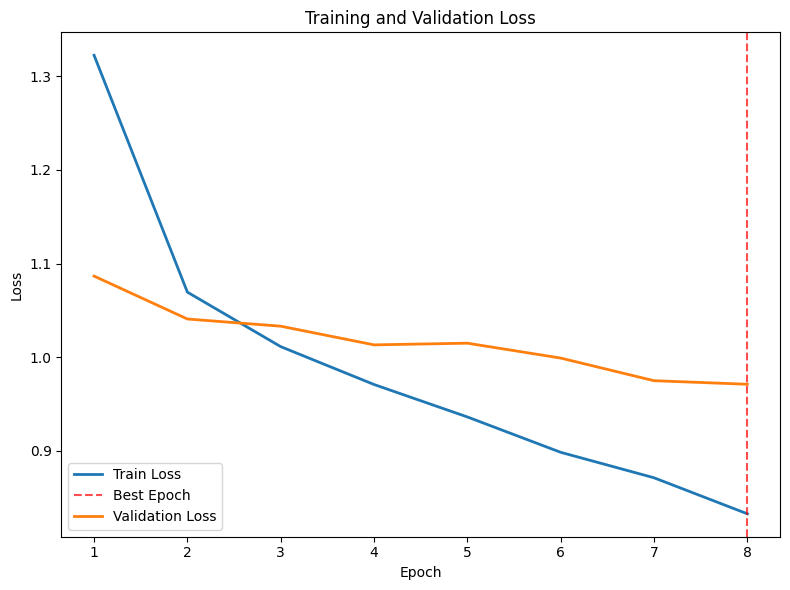

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEMO_TRAIN_SIZE = 8000
DEMO_VAL_SIZE = 2000
BATCH_SIZE = 32
NUM_EPOCHS = 50
lr = 1e-4

demo_train_dataset = Subset(train_dataset, range(DEMO_TRAIN_SIZE))
demo_val_dataset = Subset(val_dataset, range(DEMO_VAL_SIZE))

demo_train_loader = DataLoader(
    demo_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda batch: taiko_collate_fn(batch, pad_id=token_to_id["PAD"])
)

demo_val_loader = DataLoader(
    demo_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: taiko_collate_fn(batch, pad_id=token_to_id["PAD"])
)


# 重新建一个新模型，避免延续前面 smoke test 的状态
model = TaikoTransformer(
    vocab_size=len(vocab_list),
    input_dim=128,
    d_model=256,
    nhead=4,
    num_encoder_layers=4,
    num_decoder_layers=4,
    dim_feedforward=1024,
    dropout=0.1,
    max_len=512,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

criterion = nn.CrossEntropyLoss(ignore_index=token_to_id["PAD"])

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=15,
    gamma=0.5
)

train_history = fit(
    model=model,
    train_loader=demo_train_loader,
    val_loader=demo_val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=8,
    scheduler=scheduler,
)

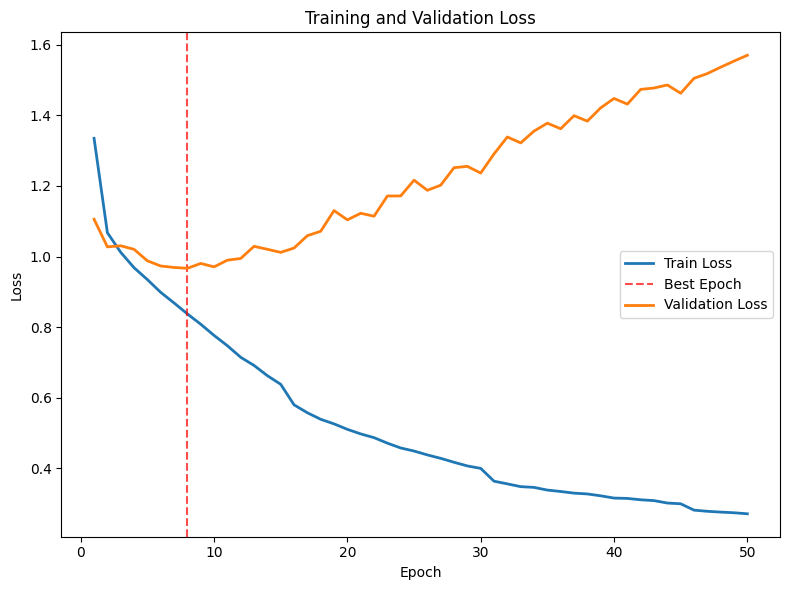

In [25]:
plot_loss(train_history)

# Generation

In [73]:
from beat_aligned_dataset import *

In [83]:
from pathlib import Path
import torch
from beat_aligned_dataset import (
    get_audio_info,
    compute_beat_grid_info,
    build_beat_aligned_frame_timeline,
    build_raw_mel_spectrogram,
    interpolate_raw_mel_to_beat_aligned_timeline,
    segment_aligned_mel_into_4beat_sequences,
)


class TaikoBeatmapGenerator:
    def __init__(self, model, token_to_id, id_to_token, device, max_len=64):
        self.model = model
        self.token_to_id = token_to_id
        self.id_to_token = id_to_token
        self.device = device
        self.max_len = max_len

    def build_timing_info(self, audio_path, offset_ms, bpm, meter=4):
        audio_path = Path(audio_path)

        if not audio_path.exists():
            raise FileNotFoundError(f"Audio file not found: {audio_path}")

        if bpm <= 0:
            raise ValueError("bpm must be positive.")

        if meter <= 0:
            raise ValueError("meter must be positive.")

        beat_duration_ms = 60000.0 / bpm

        return {
            "audio_path": str(audio_path),
            "offset_ms": float(offset_ms),
            "bpm": float(bpm),
            "meter": int(meter),
            "beat_duration_ms": float(beat_duration_ms),
        }

    @torch.no_grad()
    def greedy_decode(self, audio):
        self.model.eval()

        bos_id = self.token_to_id["BOS"]
        eos_id = self.token_to_id["EOS"]

        if audio.dim() == 2:
            audio = audio.unsqueeze(0)

        audio = audio.to(self.device)

        generated = torch.tensor([[bos_id]], dtype=torch.long, device=self.device)

        for _ in range(self.max_len):
            decoder_attention_mask = torch.ones_like(generated, device=self.device)

            logits = self.model(
                audio=audio,
                input_ids=generated,
                decoder_attention_mask=decoder_attention_mask,
            )

            next_token_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token_id], dim=1)

            if next_token_id.item() == eos_id:
                break

        generated_ids = generated[0].tolist()

        if generated_ids and generated_ids[0] == bos_id:
            generated_ids = generated_ids[1:]

        if generated_ids and generated_ids[-1] == eos_id:
            generated_ids = generated_ids[:-1]

        generated_tokens = [self.id_to_token[i] for i in generated_ids]

        return generated_ids, generated_tokens

    def preprocess_audio(self, audio_path, offset_ms, bpm, meter=4):
        timing_info = self.build_timing_info(
            audio_path=audio_path,
            offset_ms=offset_ms,
            bpm=bpm,
            meter=meter,
        )

        audio_info = get_audio_info(Path(timing_info["audio_path"]))
        waveform = audio_info["waveform"]
        sample_rate = audio_info["sample_rate"]
        audio_duration_ms = audio_info["audio_duration_ms"]

        beat_grid_info, _ = compute_beat_grid_info(
            offset_ms=timing_info["offset_ms"],
            beat_duration_ms=timing_info["beat_duration_ms"],
            audio_duration_ms=audio_duration_ms,
        )

        beat_aligned_frame_times_ms = build_beat_aligned_frame_timeline(
            offset_ms=timing_info["offset_ms"],
            beat_duration_ms=timing_info["beat_duration_ms"],
            total_frames=beat_grid_info.total_frames,
        )

        mel_spec_db, orig_frame_times_ms = build_raw_mel_spectrogram(
            waveform=waveform,
            sample_rate=sample_rate,
        )

        aligned_mel_db = interpolate_raw_mel_to_beat_aligned_timeline(
            mel_spec_db=mel_spec_db,
            orig_frame_times_ms=orig_frame_times_ms,
            beat_aligned_frame_times_ms=beat_aligned_frame_times_ms,
        )

        audio_sequences = segment_aligned_mel_into_4beat_sequences(
            aligned_mel_db=aligned_mel_db,
            total_sequences=beat_grid_info.total_sequences,
        )

        return audio_sequences

    def generate_tokens(self, audio_path, offset_ms, bpm, meter=4):
        audio_sequences = self.preprocess_audio(
            audio_path=audio_path,
            offset_ms=offset_ms,
            bpm=bpm,
            meter=meter,
        )

        all_pred_tokens = []
        all_pred_ids = []

        for seq_idx in range(len(audio_sequences)):
            audio_seq = torch.tensor(audio_sequences[seq_idx], dtype=torch.float32)
            pred_ids, pred_tokens = self.greedy_decode(audio_seq)
            all_pred_ids.append(pred_ids)
            all_pred_tokens.append(pred_tokens)

        return all_pred_tokens

    def generate_tokens_with_ids(self, audio_path, offset_ms, bpm, meter=4):
        audio_sequences = self.preprocess_audio(
            audio_path=audio_path,
            offset_ms=offset_ms,
            bpm=bpm,
            meter=meter,
        )

        all_pred_tokens = []
        all_pred_ids = []

        for seq_idx in range(len(audio_sequences)):
            audio_seq = torch.tensor(audio_sequences[seq_idx], dtype=torch.float32)
            pred_ids, pred_tokens = self.greedy_decode(audio_seq)
            all_pred_ids.append(pred_ids)
            all_pred_tokens.append(pred_tokens)

        return all_pred_ids, all_pred_tokens
    
    
    def generate_song_structure(self, audio_path, offset_ms, bpm, meter=4):
        audio_sequences = self.preprocess_audio(
            audio_path=audio_path,
            offset_ms=offset_ms,
            bpm=bpm,
            meter=meter,
        )

        song_output = []

        for seq_idx in range(len(audio_sequences)):
            audio_seq = torch.tensor(audio_sequences[seq_idx], dtype=torch.float32)
            pred_ids, pred_tokens = self.greedy_decode(audio_seq)

            start_frame = seq_idx * 192
            end_frame = start_frame + 191

            song_output.append({
                "seq_idx": seq_idx,
                "start_frame": start_frame,
                "end_frame": end_frame,
                "pred_ids": pred_ids,
                "pred_tokens": pred_tokens,
            })

        return song_output

In [ ]:
def compare_song_output_with_notes_json(song_output, gt_json_path, max_sequences=10):
    """
    Compare predicted song_output with raw notes.json.

    Inputs
    ------
    song_output : list[dict]
        Your generated output, each item like:
        {
            "seq_idx": ...,
            "start_frame": ...,
            "end_frame": ...,
            "pred_ids": [...],
            "pred_tokens": [...]
        }

    gt_json_path : str or Path
        Path to raw *.notes.json

    max_sequences : int
        Only compare first N sequences

    Returns
    -------
    str
        Human-readable comparison string
    """

    gt_json_path = Path(gt_json_path)
    if not gt_json_path.exists():
        raise FileNotFoundError(f"File not found: {gt_json_path}")

    with open(gt_json_path, "r", encoding="utf-8") as f:
        gt_data = json.load(f)

    if "notes" not in gt_data:
        raise ValueError("This file is not a raw notes.json with top-level key 'notes'.")

    raw_notes = gt_data["notes"]

    # -----------------------------
    # 1) find first bpmchange
    # -----------------------------
    bpm_events = [x for x in raw_notes if x.get("type") == "bpmchange"]
    if len(bpm_events) == 0:
        raise ValueError("No bpmchange found in notes.json, cannot infer timing.")

    first_bpm = bpm_events[0]

    offset_ms = float(first_bpm["time"])
    bpm = float(first_bpm["bpm"])
    meter = int(first_bpm["meter"]) if first_bpm["meter"] is not None else 4

    if bpm <= 0:
        raise ValueError("Invalid bpm in bpmchange.")

    beat_duration_ms = 60000.0 / bpm

    # 1 beat = TS_48 in your token system
    tick_ms = beat_duration_ms / 48.0

    # one sequence = 4 beats = 192 ticks
    seq_ticks = 192
    seq_duration_ms = tick_ms * seq_ticks

    # -----------------------------
    # 2) map raw note type -> token
    # -----------------------------
    type_to_token = {
        "don": "DON",
        "kat": "KAT",
        "bigdon": "BIGDON",
        "bigkat": "BIGKAT",
        "drumroll": "DRUMROLL",
        "sliderstart": "SLIDERSTART",
        "sliderend": "SLIDEREND",
    }

    event_notes = []
    for note in raw_notes:
        t = note.get("type")
        if t in type_to_token:
            event_notes.append({
                "time": float(note["time"]),
                "token": type_to_token[t],
            })

    # -----------------------------
    # 3) assign note events to sequence
    # -----------------------------
    seq_to_events = {}

    for ev in event_notes:
        rel_ms = ev["time"] - offset_ms

        # tolerate tiny floating errors
        seq_idx = int(math.floor((rel_ms + 1e-6) / seq_duration_ms))
        seq_idx = max(seq_idx, 0)

        seq_start_ms = offset_ms + seq_idx * seq_duration_ms
        rel_in_seq_ms = ev["time"] - seq_start_ms

        pos_tick = int(round(rel_in_seq_ms / tick_ms))

        # clamp into [0, 191]
        pos_tick = max(0, min(seq_ticks - 1, pos_tick))

        seq_to_events.setdefault(seq_idx, []).append((pos_tick, ev["token"]))

    # -----------------------------
    # 4) build GT sequence tokens
    # -----------------------------
    gt_song_output = []

    max_seq_idx_from_gt = max(seq_to_events.keys()) if seq_to_events else -1
    total_gt_sequences = max_seq_idx_from_gt + 1

    for seq_idx in range(total_gt_sequences):
        events = seq_to_events.get(seq_idx, [])
        events = sorted(events, key=lambda x: (x[0], x[1]))

        tokens = []
        cursor = 0

        for pos_tick, token in events:
            gap = pos_tick - cursor
            if gap > 0:
                tokens.append(f"TS_{gap}")
            tokens.append(token)
            cursor = pos_tick

        gt_song_output.append({
            "seq_idx": seq_idx,
            "start_frame": seq_idx * 192,
            "end_frame": seq_idx * 192 + 191,
            "tokens": tokens,
        })

    # -----------------------------
    # 5) compare as string
    # -----------------------------
    n = min(len(song_output), len(gt_song_output), max_sequences)

    lines = []
    lines.append(f"offset_ms={offset_ms}, bpm={bpm}, meter={meter}")
    lines.append("=" * 80)

    for i in range(n):
        gt_tokens = gt_song_output[i]["tokens"]
        pred_tokens = song_output[i]["pred_tokens"]

        gt_str = " ".join(gt_tokens)
        pred_str = " ".join(pred_tokens)

        lines.append(f"Sequence {i}")
        lines.append(f"GT  : {gt_str}")
        lines.append(f"PRED: {pred_str}")
        lines.append("-" * 80)

    return "\n".join(lines)

In [118]:
generator = TaikoBeatmapGenerator(
    model=model,
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    device=device,
    max_len=64,
)

song_output = generator.generate_song_structure(
    audio_path=r"D:\Study Abroad\course\DSCI498\Project\data\unpacked\34699\Hoshiful 2nd op.mp3",
    offset_ms=232,
    bpm=60000/342.857142857143,
    meter=4,
)

In [120]:
song_output

[{'seq_idx': 0,
  'start_frame': 0,
  'end_frame': 191,
  'pred_ids': [7, 48, 7, 29, 5, 29, 7, 29, 5, 29, 7],
  'pred_tokens': ['KAT',
   'TS_48',
   'KAT',
   'TS_24',
   'DON',
   'TS_24',
   'KAT',
   'TS_24',
   'DON',
   'TS_24',
   'KAT']},
 {'seq_idx': 1,
  'start_frame': 192,
  'end_frame': 383,
  'pred_ids': [5, 48, 7, 48, 5, 48, 7],
  'pred_tokens': ['DON', 'TS_48', 'KAT', 'TS_48', 'DON', 'TS_48', 'KAT']},
 {'seq_idx': 2,
  'start_frame': 384,
  'end_frame': 575,
  'pred_ids': [5, 48, 7, 48, 5, 48, 7],
  'pred_tokens': ['DON', 'TS_48', 'KAT', 'TS_48', 'DON', 'TS_48', 'KAT']},
 {'seq_idx': 3,
  'start_frame': 576,
  'end_frame': 767,
  'pred_ids': [5, 48, 7, 29, 5, 29, 7, 29, 5, 29, 7, 29, 5],
  'pred_tokens': ['DON',
   'TS_48',
   'KAT',
   'TS_24',
   'DON',
   'TS_24',
   'KAT',
   'TS_24',
   'DON',
   'TS_24',
   'KAT',
   'TS_24',
   'DON']},
 {'seq_idx': 4,
  'start_frame': 768,
  'end_frame': 959,
  'pred_ids': [5, 48, 7, 29, 5, 29, 7, 29, 5, 29, 7, 29, 5],
  'pred_to

In [119]:
result_str = compare_song_output_with_notes_json(
    song_output=song_output,
    gt_json_path=r"D:\Study Abroad\course\DSCI498\Project\data\unpacked\34699\parsed\Chata - Mirai no Monogatari (Short Ver.) (hoLysoup) [i_k's Taiko].notes.json",
    max_sequences=100,
)

print(result_str)

offset_ms=232.0, bpm=174.99999999999991, meter=4
Sequence 0
GT  : TS_48 DON TS_48 KAT TS_72 DON
PRED: KAT TS_48 KAT TS_24 DON TS_24 KAT TS_24 DON TS_24 KAT
--------------------------------------------------------------------------------
Sequence 1
GT  : TS_24 DON TS_48 KAT TS_72 KAT TS_12 KAT TS_12 KAT TS_12 KAT
PRED: DON TS_48 KAT TS_48 DON TS_48 KAT
--------------------------------------------------------------------------------
Sequence 2
GT  : DON TS_24 KAT TS_24 DON TS_24 KAT TS_24 KAT TS_24 DON TS_24 DON TS_12 DON TS_12 KAT
PRED: DON TS_48 KAT TS_48 DON TS_48 KAT
--------------------------------------------------------------------------------
Sequence 3
GT  : KAT TS_24 DON TS_24 KAT TS_48 KAT TS_48 DON TS_12 DON TS_12 KAT TS_12 KAT
PRED: DON TS_48 KAT TS_24 DON TS_24 KAT TS_24 DON TS_24 KAT TS_24 DON
--------------------------------------------------------------------------------
Sequence 4
GT  : KAT TS_24 DON TS_24 KAT TS_48 DON TS_24 KAT TS_12 KAT TS_12 KAT TS_24 DON
PRED: DON 